In [1]:
import numpy as np

# y = 1
# prediction = 0.01

# cost = -(
#     y * np.log(prediction)
#     + (1-y) * np.log(1-prediction)
# )

# print(cost)

# ALL MODELS FROM SCRATCH USING ONLY NUMPY

In [2]:
class multiple_lin_reg:
    def __init__(self, epochs = 1000, alpha = 0.01):
        self.w = None
        self.b = 0
        self.epochs = epochs
        self.alpha = alpha
        self.cost_history = []
    def predict(self, X):
        return np.dot(X, self.w) + self.b
    
    def compute_cost(self, X, y):
        m = len(y)
        predictions = self.predict(X)
        cost = (1/m) * np.sum((predictions - y) ** 2)
        return cost
    
    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0
        for epoch in range(self.epochs):
            predictions = self.predict(X)
            dw = (1/m)*np.dot(X.T,(predictions - y))
            db = (1/m)*np.sum(predictions - y)
            self.w = self.w - self.alpha * dw
            self.b = self.b - self.alpha * db
            cost = self.compute_cost(X, y)
            self.cost_history.append(cost)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Cost: {cost}")

In [9]:
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
y = np.array([3, 5, 7, 9])
model = multiple_lin_reg(epochs=1000, alpha=0.01)
model.fit(X, y)
predictions = model.predict(X)
print("Predictions:", predictions)
print("Weights:", model.w)
print("Bias:", model.b)
print("Cost History:", model.cost_history)
Accuracy = 1 - np.mean(np.abs(predictions - y) / y)
print("Accuracy:", Accuracy)


Epoch 0, Cost: 25.062524999999997
Epoch 100, Cost: 0.014889482434534765
Epoch 200, Cost: 0.010556770811213534
Epoch 300, Cost: 0.007484841091722741
Epoch 400, Cost: 0.005306816560688597
Epoch 500, Cost: 0.003762578478779262
Epoch 600, Cost: 0.002667700427756219
Epoch 700, Cost: 0.0018914224945441038
Epoch 800, Cost: 0.0013410347787350728
Epoch 900, Cost: 0.0009508051654056619
Predictions: [3.04149307 5.01951621 6.99753934 8.97556247]
Weights: [0.96419211 1.01383102]
Bias: 0.04963891563219448
Cost History: [np.float64(25.062524999999997), np.float64(15.323377550624999), np.float64(9.371922607719704), np.float64(5.735062147783246), np.float64(3.5126110546949354), np.float64(2.154481533519421), np.float64(1.3245243002581704), np.float64(0.8173242516457568), np.float64(0.5073557159043498), np.float64(0.31791209234891404), np.float64(0.2021192832678242), np.float64(0.1313333254800258), np.float64(0.088050380564083), np.float64(0.061574150627646346), np.float64(0.04536830986663215), np.float

In [10]:
class Linear_reg:
    def __init__(self,epochs = 1000, alpha = 0.01):
        self.w = 0
        self.b = 0
        self.epochs = epochs
        self.alpha = alpha
        self.cost_history = []
    def predict(self, X):
        return self.w * X + self.b
    def compute_cost(self, X, y):
        m = len(y)
        predictions = self.predict(X)
        cost = (1/m) * np.sum((predictions - y) ** 2)
        return cost
    def fit(self, X, y):
        m = len(y)
        self.w = 0
        self.b = 0
        for epoch in range(self.epochs):
            predictions = self.predict(X)

            dw = (1/m)*np.sum((predictions - y) * X)
            db = (1/m)*np.sum(predictions - y)

            self.w -= self.alpha * dw
            self.b -= self.alpha * db

            self.cost_history.append(self.compute_cost(X, y))
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Cost: {self.cost_history[-1]}")
X = np.array([1, 2, 3, 4])
y = np.array([3, 5, 7, 9])
model = Linear_reg(epochs=1000, alpha=0.01)
model.fit(X, y)
predictions = model.predict(X)
print("Predictions:", predictions)
print("Weight:", model.w)
print("Bias:", model.b)
print("Cost History:", model.cost_history)
Accuracy = 1 - np.mean(np.abs(predictions - y) / y)
print("Accuracy:", Accuracy)

Epoch 0, Cost: 34.4407875
Epoch 100, Cost: 0.010137287674933673
Epoch 200, Cost: 0.007512101715620174
Epoch 300, Cost: 0.005567247159379509
Epoch 400, Cost: 0.004125908049044758
Epoch 500, Cost: 0.0030577261511539515
Epoch 600, Cost: 0.0022660924829906066
Epoch 700, Cost: 0.0016794097599383095
Epoch 800, Cost: 0.0012446169619934806
Epoch 900, Cost: 0.0009223903653738292
Predictions: [2.95771981 4.97951235 7.0013049  9.02309744]
Weight: 2.021792543655329
Bias: 0.935927264124864
Cost History: [np.float64(34.4407875), np.float64(28.9312612271875), np.float64(24.30343640984733), np.float64(20.41621143999057), np.float64(17.151065670922293), np.float64(14.408445710626175), np.float64(12.104730028681978), np.float64(10.169679327270806), np.float64(8.544294937819554), np.float64(7.179019945579421), np.float64(6.032228194243146), np.float64(5.068955100197334), np.float64(4.259831578806781), np.float64(3.5801885780342806), np.float64(3.0093049165344947), np.float64(2.529775492728532), np.float6

In [11]:
class logistic:
    def __init__(self,epochs = 1000, alpha = 0.01):
        self.w = None
        self.b = 0
        self.epochs = epochs
        self.alpha = alpha
        self.cost_history = []
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    def predict(self, X):
        linear_model = np.dot(X, self.w) + self.b
        return self.sigmoid(linear_model)
    def compute_cost(self, X, y):
        m = len(y)
        predictions = self.predict(X)
        cost = -(1/m) * np.sum(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
        return cost
    def fit(self, X, y):
        m , n = X.shape
        self.w = np.zeros(n)
        self.b = 0
        for epoch in range(self.epochs):
            predictions = self.predict(X)

            dw = (1/m)*np.dot(X.T,(predictions - y))
            db = (1/m)*np.sum(predictions - y)

            self.w -= self.alpha * dw
            self.b -= self.alpha * db

            if epoch % 100 == 0:
                cost = self.compute_cost(X, y)
                self.cost_history.append(cost)
                print(f"Epoch {epoch}, Cost: {cost}")

X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
y = np.array([0, 0, 1, 1])
model = logistic(epochs=1000, alpha=0.01)
model.fit(X, y)
predictions = model.predict(X)
print("Predictions:", predictions)
print("Weights:", model.w)
print("Bias:", model.b)
print("Cost History:", model.cost_history)
predicted_classes = (predictions >= 0.5).astype(int)
accuracy = np.mean(predicted_classes == y)
print("Accuracy:", accuracy)


Epoch 0, Cost: 0.6882752976930092
Epoch 100, Cost: 0.6192473344588314
Epoch 200, Cost: 0.5918050256614301
Epoch 300, Cost: 0.5664971536111676
Epoch 400, Cost: 0.5431464554886535
Epoch 500, Cost: 0.5215861469854124
Epoch 600, Cost: 0.50165983328661
Epoch 700, Cost: 0.4832223064333259
Epoch 800, Cost: 0.4661398091261502
Epoch 900, Cost: 0.45028990329819
Predictions: [0.34961942 0.52123365 0.68797817 0.81703428]
Weights: [ 0.91260242 -0.20690417]
Bias: -1.1195065937669515
Cost History: [np.float64(0.6882752976930092), np.float64(0.6192473344588314), np.float64(0.5918050256614301), np.float64(0.5664971536111676), np.float64(0.5431464554886535), np.float64(0.5215861469854124), np.float64(0.50165983328661), np.float64(0.4832223064333259), np.float64(0.4661398091261502), np.float64(0.45028990329819)]
Accuracy: 0.75


Epoch 0, Cost: 1111.5460
Epoch 100, Cost: 38.8171
Epoch 200, Cost: 26.4032
Epoch 300, Cost: 18.0789
Epoch 400, Cost: 12.4969
Epoch 500, Cost: 8.7538
Epoch 600, Cost: 6.2438
Epoch 700, Cost: 4.5607
Epoch 800, Cost: 3.4320
Epoch 900, Cost: 2.6752
Epoch 1000, Cost: 2.1677
Epoch 1100, Cost: 1.8274
Epoch 1200, Cost: 1.5992
Epoch 1300, Cost: 1.4462
Epoch 1400, Cost: 1.3435
Epoch 1500, Cost: 1.2747
Epoch 1600, Cost: 1.2286
Epoch 1700, Cost: 1.1977
Epoch 1800, Cost: 1.1769
Epoch 1900, Cost: 1.1630
Epoch 2000, Cost: 1.1537
Epoch 2100, Cost: 1.1474
Epoch 2200, Cost: 1.1432
Epoch 2300, Cost: 1.1404
Epoch 2400, Cost: 1.1385
Epoch 2500, Cost: 1.1372
Epoch 2600, Cost: 1.1364
Epoch 2700, Cost: 1.1358
Epoch 2800, Cost: 1.1354
Epoch 2900, Cost: 1.1352
Epoch 3000, Cost: 1.1350
Epoch 3100, Cost: 1.1349
Epoch 3200, Cost: 1.1348
Epoch 3300, Cost: 1.1348
Epoch 3400, Cost: 1.1347
Epoch 3500, Cost: 1.1347
Epoch 3600, Cost: 1.1347
Epoch 3700, Cost: 1.1347
Epoch 3800, Cost: 1.1347
Epoch 3900, Cost: 1.1347
Epoch

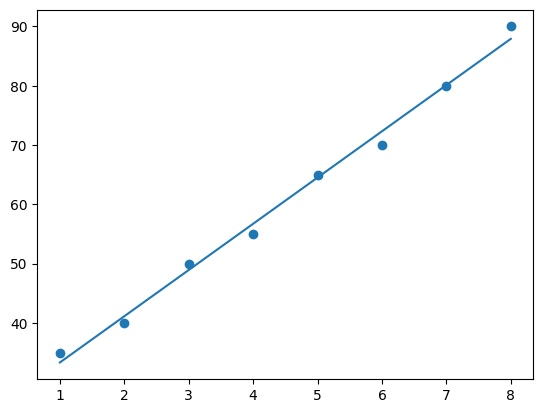

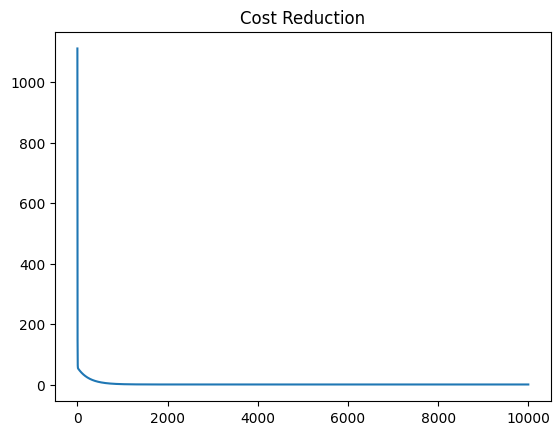

In [11]:
import numpy as np
import matplotlib.pyplot as plt

class apna_regression:

    def __init__(self):
        self.w = 0
        self.b = 0

    def predict(self,X):
        return self.w * X + self.b
    
    def compute_cost(self,X,y):
        m = len(X)
        predictions = self.predict(X)

        cost = (1/(2*m)) * np.sum((predictions - y) **2)

        return cost
    
    def fit(self, X,y,epochs = 10000, lr = 0.01):
        m = len(X)

        cost_history = []

        for epoch in range(epochs):

            predictions = self.predict(X)

            dw = (1/m) * np.sum((predictions - y)*X)
            db = (1/m) * np.sum(predictions - y)

            self.w -= lr * dw
            self.b -= lr * db

            cost = self.compute_cost(X,y)
            cost_history.append(cost)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Cost: {cost:.4f}")
        return cost_history





X = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y = np.array([35, 40, 50, 55, 65, 70, 80, 90])

model = apna_regression()

costs = model.fit(X, y)

print("Weight:", model.w)
print("Bias:", model.b)

prediction = model.predict(13)

print("Prediction:", prediction)

plt.scatter(X, y)

plt.plot(X, model.predict(X))

plt.show()

plt.plot(costs)

plt.title("Cost Reduction")

plt.show()
